In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [74]:
def raiz_bisec(f,xi,xd,error = 1e-8):
    fi , fd = f(xi) , f(xd)
    if fi*fd < 0:
        x_med = 0.5*(xi+xd)
        f_med = f(x_med)
        contador = 0
        while abs(f_med) > error or abs(xd-xi) > error:
            if fi*f_med < 0:
                xd = x_med
            else:
                xi = x_med
            x_med = 0.5*(xi+xd)
            f_med = f(x_med)
            contador += 1
        raiz = x_med
    else:
        print('En el intervalo no hay raices')
        raiz = np.nan
    print('Iteraciones = ',contador) 
    return raiz

Iteraciones =  30
2.3025850928388536 -1.5519212581693864e-09


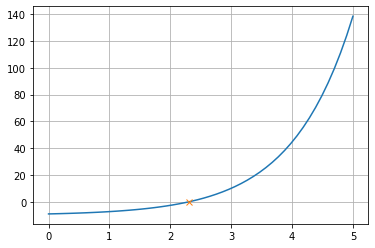

In [75]:
x = np.linspace(0,5)
def LF_Ivan(x):
    return np.exp(x)-10
y = LF_Ivan(x)
raiz = raiz_bisec(LF_Ivan,0,5)
print(raiz,LF_Ivan(raiz))
plt.plot(x,y)
plt.plot(raiz,0,'x')
plt.grid()
plt.show()

In [76]:
def LF_otro_Ivan(x):
    return x**15

Iteraciones =  30
-3.77185621614039e-09 -4.44966109890143e-127


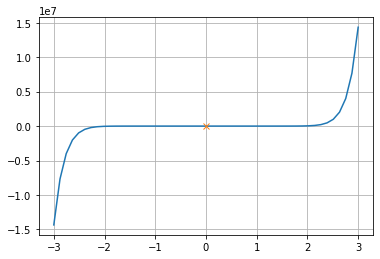

In [77]:
x = np.linspace(-3,3)
y = LF_otro_Ivan(x)
raiz = raiz_bisec(LF_otro_Ivan,-4.1,6)
print(raiz,LF_otro_Ivan(raiz))
plt.plot(x,y)
plt.plot(raiz,0,'x')
plt.grid()
plt.show()

In [82]:
def Newton_c_df(f,x0,df,error=1e-8):
    f_x = f(x0)
    contador = 0
    while abs(f_x) > error:
        x0 = x0 - f_x/df(x0)
        f_x = f(x0)
        contador += 1
    print('Iteraciones = ',contador) 
    return x0

def Newton_num(f,x0,error=1e-8):
    f_x = f(x0)
    contador = 0
    while abs(f_x) > error:
        df_x = (f(x0+error) - f(x0-error))/(2*error)
        x0 = x0 - f_x/df_x
        f_x = f(x0)
        contador += 1
    print('Iteraciones = ',contador) 
    return x0

In [81]:
def deriv_LF_Ivan(x):
    return np.exp(x)
raiz = Newton_c_df(LF_Ivan,3,deriv_LF_Ivan)
print(raiz)

Iteraciones =  5
2.302585092994046


In [83]:
raiz = Newton_num(LF_Ivan,3)
print(raiz)

Iteraciones =  5
2.3025850929940455


In [91]:
import scipy.special as ss
def mi_airy(x):
    return ss.airy(x)[0]

Iteraciones =  4
-2.3381074163748776


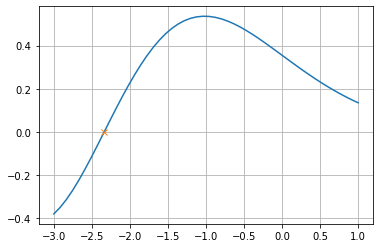

In [95]:
x = np.linspace(-3,1)
y = ss.airy(x)
raiz = Newton_num(mi_airy,-3)
print(raiz)
plt.plot(x,y[0])
plt.plot(raiz,0,'x')
plt.grid()
plt.show()